In [193]:
#Importing the Essential libraries for my EDA and charts
import pandas as pd ## for data manipulation
import numpy as np # for numerical analysis
import matplotlib.pyplot as plt
import plotly.express as px  # For interactive data visualization

##Turning off warnings
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [194]:
import os

In [195]:
%pwd


'c:\\Users\\DONATUS\\Desktop\\bank_fraud'

In [196]:
#importing the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Donatus-Victor/fraud_detection/refs/heads/main/payment_transactions.csv")

df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [197]:
## Data preparation
## Handle missing values, fix data types, clean categorical fields, and extract useful time-based features
## from the timestamp. Address class imbalance if necessary.
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')

### Data Inspection

In [198]:
#Top five rows
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [199]:
## Last five rows 
df.tail()


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
10195,a5c6391d-4763-4ed6-a5ef-80b744cf71b2,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-11-25 16:25:46.468549+00:00,US,USD,GBP,mobile,127.91,127.91,2.97,...,0.315,standard,1018,0.934,0,0.087,0,0,0.0,0
10196,35c133e7-7279-4d24-ac0e-967675f2c2a0,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2023-01-13 16:50:48.468549+00:00,US,USD,CNY,ATM,286.59,286.59,5.12,...,0.383,enhanced,257,0.894,0,0.257,0,0,0.0,0
10197,6263d697-0900-440c-99d7-b4be90e733b5,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2025-07-02 11:33:48.468549+00:00,US,USD,USD,mobile,230.09,230.09,4.01,...,0.244,enhanced,367,0.939,0,0.176,0,0,0.0,0
10198,883403f5-fd2f-4b39-824e-9710485a983e,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2023-01-01 02:40:14.468549+00:00,UK,GBP,PHP,mobile,-168.96,211.20,9999.99,...,1.200,standard,4,-0.100,0,0.407,-1,0,0.0,0
10199,f122f3ba-42fc-4018-85d1-57e71b525691,a07adabc-9a06-4e28-b1d6-83b128f4219a,2023-07-28 19:12:42.468549+00:00,US,USD,EUR,mobile,65.43,65.43,2.11,...,0.182,standard,859,0.810,0,0.363,0,0,0.0,0


In [200]:
# Checking te data types 
df.dtypes

transaction_id                   str
customer_id                      str
timestamp                        str
home_country                     str
source_currency                  str
dest_currency                    str
channel                          str
amount_src                       str
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                        str
new_device                      bool
ip_address                       str
ip_country                       str
location_mismatch               bool
ip_risk_score                float64
kyc_tier                         str
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

In [201]:
df.shape

(10200, 26)

In [202]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')

In [203]:
# Summary Statustics 
df.describe()

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,9895.000000,9905.000000,10200.000000,10200.000000,10200.000000,9905.000000,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000
mean,410.973958,110.915958,151.070118,0.355567,422.387353,0.684846,0.002549,0.241320,0.131471,0.232255,0.042412,0.019314
std,1428.534323,1013.983451,360.401932,0.230242,339.577111,0.254493,0.052334,0.103254,0.950315,0.981683,0.083074,0.137632
min,7.230000,-1.000000,0.592000,0.004000,4.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,88.260000,2.310000,1.000000,0.200000,257.000000,0.522000,0.000000,0.166000,0.000000,0.000000,0.000000,0.000000
50%,151.890000,3.330000,7.142857,0.308000,298.000000,0.779000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,267.935000,5.040000,61.666667,0.440000,718.000000,0.923000,0.000000,0.332000,0.000000,0.000000,0.000000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1092.000000,0.971000,2.000000,0.554000,8.000000,9.000000,0.250000,1.000000


In [204]:
# Display Index, Columns, and Data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10200 non-null  str    
 1   customer_id                10200 non-null  str    
 2   timestamp                  10171 non-null  str    
 3   home_country               10200 non-null  str    
 4   source_currency            10200 non-null  str    
 5   dest_currency              10200 non-null  str    
 6   channel                    10200 non-null  str    
 7   amount_src                 10200 non-null  str    
 8   amount_usd                 9895 non-null   float64
 9   fee                        9905 non-null   float64
 10  exchange_rate_src_to_dest  10200 non-null  float64
 11  device_id                  10200 non-null  str    
 12  new_device                 10200 non-null  bool   
 13  ip_address                 9895 non-null   str    
 14  i

In [205]:
#checking the shape of the data
df.shape

(10200, 26)

In [206]:
## checking for missing values
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

## Handling Missing Value

In [207]:
#making a copy of the original dataset
df2 = df.copy()

In [208]:
df2.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [209]:
# Showing all rows that have at least one missing value
missing_rows = df2[df2.isnull().any(axis=1)]

missing_rows.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
13,1a34a095-3be4-4a69-a22e-803be566526c,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2022-10-05 07:04:39.468549+00:00,UK,GBP,EUR,mobile,322.24,NaN,NaN,...,0.245,NaN,4,NaN,0,0.407,0,0,0.05,0
49,b489474c-b729-4759-86e9-51778ddea385,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-08 20:45:48.468549+00:00,US,USD,INR,mobile,255.06,NaN,NaN,...,0.530,NaN,263,NaN,0,0.223,0,0,0.00,0
151,32cbd613-5c6c-4797-be15-165bc408c2ca,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-10-20 22:08:59.468549+00:00,US,USD,MXN,mobile,502.97,NaN,NaN,...,0.310,NaN,1018,NaN,0,0.087,0,0,0.20,0
158,e6ef7b85-c19f-43fa-befa-743e37c62583,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,PHP,mobile,248.92,248.92,5.56,...,0.197,enhanced,367,0.939,0,0.176,0,0,0.10,0
160,2b64ca36-f140-4de4-9cc8-c678255402a9,d71c91b4-fee8-4104-9856-a5c6109a62e3,NaN,US,USD,CNY,web,75.44,75.44,1.31,...,0.353,standard,298,0.336,0,0.166,0,0,0.00,0


In [210]:
##checking the shape of total missing values
missing_rows.shape

(334, 26)

In [211]:
# Total percentage of missing values in the DataFrame
total_missing_percent = (df2.isnull().sum().sum() / (df.shape[0] * df2.shape[1])) * 100

print(f"Total missing percentage: {total_missing_percent:.2f}%")

Total missing percentage: 0.69%


In [212]:
# Converting timestamp to proper datetime
df2["timestamp"] = pd.to_datetime(df2["timestamp"], errors="coerce")

# Extracting time-based features
df2["hour"] = df2["timestamp"].dt.hour                 # 0–23
df2["day_of_week"] = df2["timestamp"].dt.day_name()    # Monday, Tuesday, etc.
df2["is_weekend"] = df2["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

#Handling missing values created from invalid timestamps
# Filling numeric columns with unknown

df2[["hour", "day_of_week", "is_weekend"]] = df2[["hour", "day_of_week", "is_weekend"]].fillna(-1)
# Fill categorical column with a string marker
df2["day_of_week"] = df2["day_of_week"].fillna("Unknown")
df2["timestamp"] = df2["timestamp"].fillna("Unknown")



In [213]:
df2.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'hour', 'day_of_week',
       'is_weekend'],
      dtype='str')

In [214]:
# Removing any whitespace(s)
df2['amount_src'] = df2['amount_src'].str.replace(' ', '')  # Remove any spaces

# Converting to numeric, setting errors='coerce' to handle non-convertible values
df2['amount_src'] = pd.to_numeric(df2['amount_src'], errors='coerce')

In [215]:
#Function to calculate the mean of some numeric columns
def calculate_mean(df2, column_name):
    if column_name in df2.columns:
        return df2[column_name].mean()
    else:
        return "Column not found!"

# using the function
amount_usd = calculate_mean(df2, 'amount_usd')
device_trust_score = calculate_mean(df, 'device_trust_score')
fee = calculate_mean(df2, 'fee')

print("Mean of amount_usd:", amount_usd)
print("Mean of device_trust_score:", device_trust_score)
print("Mean of fee:", fee)


Mean of amount_usd: 410.9739575543204
Mean of device_trust_score: 0.684846340232206
Mean of fee: 110.91595759717315


In [216]:
# Numeric missing value handling using mean of each column to fill the missing values
num_fill_cols = [
    "amount_usd", "fee", "device_trust_score", "amount_src"
]

for col in num_fill_cols:
    if col in df2.columns:
        mean_value = round(df2[col].mean(), 2)  # Rounding the mean to two decimal places
        # FIX: fill on df2 (the cleaned frame), not df (the original, unconverted frame) —
        # filling from `df` was silently re-introducing the whitespace/type issues we fixed earlier.
        df2[col] = df2[col].fillna(mean_value)


In [217]:
# Categorical missing value handling
cat_fill_cols = [
    "ip_address", "ip_country", "kyc_tier"
]

for col in cat_fill_cols:
    if col in df2.columns:
        df2[col] = df2[col].fillna("unknown")  # Fill missing values with "unknown"

In [218]:
#Checking for missing values again
df2.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day_of_week                  0
is_weekend                   0
dtype: int64

In [219]:
# converting timestamp to datetime
df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')

# Extracting year, filling NaNs with 0
df2['year'] = df2['timestamp'].dt.year.fillna(0).astype(int)



## Insights and charts

In [220]:

# Creating a bar plot
fig_day = px.bar(
    df2.groupby('day_of_week').size().reset_index(name='number_of_deposits'),
    x='day_of_week', 
    y='number_of_deposits',
    title='Number of Deposits by Day of the Week',
    labels={'number_of_deposits': 'Number of Deposits', 'day_of_week': 'Day of the Week'},
    text='number_of_deposits'
)

# Setting colors and hover template
fig_day.update_traces(marker_color='green', hovertemplate='Total Deposits: %{y}<extra></extra>')

# Displaying the figure
fig_day.show()

In [221]:
# 1. Force amount_src to numeric (float) before grouping
df2['amount_src'] = pd.to_numeric(df2['amount_src'], errors='coerce')

# 2. Grouping by home_country and summing amounts
country_amount = df2.groupby('home_country')['amount_src'].sum().reset_index(name='total_amount')

# 3. Rounding total_amount to 2 decimal places (This will work perfectly now!)
country_amount['total_amount'] = country_amount['total_amount'].round(2)

# Creating the bar plot for total amount by Home Country
fig_country = px.bar(
    country_amount,
    x='home_country', 
    y='total_amount',
    title='Total Amount by Home Country',
    labels={'total_amount': 'Total Amount', 'home_country': 'Home Country'},
    text='total_amount'  # Adding values on top of the bars
)

# Setting colors and hover template
fig_country.update_traces(marker_color='green', hovertemplate='Total Amount: %{y}<extra></extra>')

# Displaying the figure
fig_country.show()

In [222]:

# # Grouping by home_country and summing amounts
# country_amount = df2.groupby('home_country')['amount_src'].sum().reset_index(name='total_amount')

# # Rounding total_amount to 2 decimal places
# country_amount['total_amount'] = country_amount['total_amount'].round(2)

# # Creating the bar plot for total amount by Home Country
# fig_country = px.bar(
#     country_amount,
#     x='home_country', 
#     y='total_amount',
#     title='Total Amount by Home Country',
#     labels={'total_amount': 'Total Amount', 'home_country': 'Home Country'},
#     text='total_amount'  # Adding values on top of the bars
# )

# # Setting colors and hover template
# fig_country.update_traces(marker_color='green', hovertemplate='Total Amount: %{y}<extra></extra>')

# # Displaying the figure
# fig_country.show()

In [223]:
##finding the total sum in USD
total_amount = df2['amount_src'].sum()
print("Total sum of amount:", total_amount)

Total sum of amount: 4030938.0500000003


In [224]:
##finding the total sum of feein USD
total_fee = df2['fee'].sum()
print("Total sum of the fee:", fee)

Total sum of the fee: 110.91595759717315


In [225]:
##Finding the total fraud count
total_amount = df2['is_fraud'].sum()
print("Total sum of the amount:", total_amount)

Total sum of the amount: 197


In [226]:

# Grouping by home_country and summing the number of frauds
country_fraud = df2.groupby('home_country')['is_fraud'].sum().reset_index(name='total_fraud')

# Create the bar plot for total fraud transactions by home country
fig_country_fraud = px.bar(
    country_fraud,
    x='home_country', 
    y='total_fraud',
    title='Total Fraud Transactions by Home Country',
    labels={'total_fraud': 'Total Fraud Transactions', 'home_country': 'Home Country'},
    text='total_fraud'  # Adding values on top of the bars
)

# Setting colors and hover template
fig_country_fraud.update_traces(marker_color='green', hovertemplate='Total Fraud: %{y}<extra></extra>')

# Displaying the figure
fig_country_fraud.show()

In [227]:
df2['chargeback_history_count'].value_counts()

chargeback_history_count
0    10175
1       24
2        1
Name: count, dtype: int64

In [228]:
df2['kyc_tier'].value_counts()

kyc_tier
standard       7401
enhanced       1715
low             483
unknown         332
standrd          72
STANDARD         70
 standard        65
 enhanced        17
ENHANCED         17
enhancd          12
 low              8
LOW               5
 nan              2
NAN               1
Name: count, dtype: int64

In [229]:

# Standardizing kyc_tier values
df2['kyc_tier'] = df2['kyc_tier'].str.strip().str.lower().replace({
    'standrd': 'standard',
    'enhancd': 'enhanced',
    'nan': 'unknown'
}).fillna('unknown')

# FIX: check what we're about to drop, and how much fraud is in it, BEFORE filtering.
# The original code filtered silently, which risks quietly deleting minority-class (fraud) rows.
valid_kyc_tiers = ['standard', 'enhanced', 'low', 'unknown']
invalid_mask = ~df2['kyc_tier'].isin(valid_kyc_tiers)
print(f"Rows with unexpected kyc_tier values: {invalid_mask.sum()} "
      f"({df2.loc[invalid_mask, 'is_fraud'].sum()} of them fraud)")
print(df2.loc[invalid_mask, 'kyc_tier'].value_counts())

# Retain only necessary values
df2 = df2[df2['kyc_tier'].isin(valid_kyc_tiers)]


Rows with unexpected kyc_tier values: 0 (0 of them fraud)
Series([], Name: count, dtype: int64)


In [230]:
df2['kyc_tier'].value_counts()

kyc_tier
standard    7608
enhanced    1761
low          496
unknown      335
Name: count, dtype: int64

In [231]:
df2.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour,day_of_week,is_weekend,year
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0,0.223,0,0,0.0,0,18.0,Monday,0,2022
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0,0.268,0,1,0.0,0,20.0,Monday,0,2022
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0,0.176,0,0,0.0,0,23.0,Monday,0,2022
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0,0.391,0,0,0.0,0,1.0,Tuesday,0,2022
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0,0.257,0,0,0.0,0,9.0,Tuesday,0,2022


In [232]:
df2.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'hour', 'day_of_week',
       'is_weekend', 'year'],
      dtype='str')

In [233]:
df2['is_fraud'].value_counts()

is_fraud
0    10003
1      197
Name: count, dtype: int64

In [234]:
## Dropping unwanted columns

# FIX: previously dropped columns like ip_risk_score, location_mismatch, new_device,
# corridor_risk, chargeback_history_count, txn_velocity_1h, hour, and is_weekend.
# These are exactly the behavioral/risk signals that tend to matter most for fraud
# detection, so they're kept below. Only true identifiers / raw non-numeric fields
# and clearly redundant columns are dropped.
df2 = df2.drop(columns=['customer_id', 'transaction_id', 'timestamp', 'device_id',
                         'ip_address', 'ip_country', 'exchange_rate_src_to_dest', 'year'])


In [235]:

df2.head()
df2.to_csv("cleaned_data_for_web_app.csv", index=False)


In [236]:
df2['dest_currency'].value_counts()

dest_currency
USD    1253
CNY    1237
GBP    1208
CAD    1204
NGN    1190
INR    1164
PHP    1155
EUR    1113
MXN     676
Name: count, dtype: int64

In [237]:
# Drop rows where all values are NaN
df2 = df2.dropna(how='all')


In [238]:
# Define the replacement dictionary
channel_replacements = {
    'mobille': 'mobile',
    ' mobile': 'mobile',
    'MOBILE': 'mobile',
    'WEB': 'web',
    ' web': 'web',
    'weeb': 'web',
    'ATm': 'ATM',
    ' ATM': 'ATM',
    'unknown': 'unknown'
}

# Apply the replacements using the dictionary
df2['channel'] = df2['channel'].replace(channel_replacements)

# Optional: If you want to standardize casing and remove leading/trailing spaces
df2['channel'] = df2['channel'].str.strip().str.lower()

# Verify the result
channel_counts = df2['channel'].value_counts()
print(channel_counts)

channel
mobile     6063
web        3179
atm         921
unknown      37
Name: count, dtype: int64


In [239]:
# Grouping by channel and sum amount_src
kyc_amount = df2.groupby('channel')['amount_src'].sum().reset_index(name='total_amount')

# Create the pie chart
fig_kyc = px.pie(
    kyc_amount,
    names='channel', 
    values='total_amount',
    title='Total Amount by Channel'
)

# Display the figure
fig_kyc.show()

In [240]:
df2['home_country'].value_counts()


home_country
US         7287
UK         1797
CA          996
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64

In [241]:
# Define the replacement dictionary
home_country_replacements = {
    ' US': 'US',
    ' UK': 'UK',
    ' CA': 'CA',
    'unknown': 'unknown'
}

# Apply the replacements using the dictionary
df2['home_country'] = df2['home_country'].replace(home_country_replacements)

# Optional: If you want to standardize casing and remove leading/trailing spaces
df2['home_country'] = df2['home_country'].str.strip().str.lower()

# Verify the result
home_country_counts = df2['home_country'].value_counts()
print(home_country_counts)

home_country
us         7355
uk         1810
ca         1003
unknown      32
Name: count, dtype: int64


In [242]:
df2.columns

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'new_device', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'hour', 'day_of_week',
       'is_weekend'],
      dtype='str')

In [243]:
df2['source_currency'].value_counts()

source_currency
USD    7378
GBP    1817
CAD    1005
Name: count, dtype: int64

In [244]:
df2['dest_currency'].value_counts()

dest_currency
USD    1253
CNY    1237
GBP    1208
CAD    1204
NGN    1190
INR    1164
PHP    1155
EUR    1113
MXN     676
Name: count, dtype: int64

In [245]:
#df2['location_mismatch'].value_counts()

In [246]:
df2['day_of_week'].value_counts()

day_of_week
Monday       1500
Thursday     1488
Friday       1466
Tuesday      1428
Saturday     1428
Wednesday    1421
Sunday       1408
-1             61
Name: count, dtype: int64

In [247]:
# Replaceing -1 with unknown in the weekday column
df2['day_of_week'] = df2['day_of_week'].replace(-1, 'unknown')

# Verify the result
day_of_week_counts = df2['day_of_week'].value_counts()
print(day_of_week_counts)

day_of_week
Monday       1500
Thursday     1488
Friday       1466
Tuesday      1428
Saturday     1428
Wednesday    1421
Sunday       1408
unknown        61
Name: count, dtype: int64


## Modeling — leakage-safe pipeline (train / test only)

Just a train (80%) / test (20%) split, as requested. The one thing this changes vs. a 3-way split: the decision threshold can't be tuned by peeking at `y_test` anymore (that would leak the test set into a modeling decision). Instead, the threshold is tuned using **cross-validation on the training set only** — the test set is never touched until the final report at the very end.

Everything else from before still applies:
- encoder + scaler are fit only on `X_train` (inside a `Pipeline`, no leakage),
- `OneHotEncoder` instead of `LabelEncoder` (no false ordering, handles unseen categories),
- one saved pipeline file bundles preprocessing + model for correct inference.


In [248]:
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


### 1. Train / test split (80% / 20%)


In [249]:
X = df2.drop(columns=['is_fraud'])
y = df2['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=10
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Fraud rate — train: %.4f | test: %.4f" % (y_train.mean(), y_test.mean()))


Train: (8160, 21)  Test: (2040, 21)
Fraud rate — train: 0.0194 | test: 0.0191


### 2. Preprocessing + model in one pipeline

- `OneHotEncoder(handle_unknown='ignore')` instead of `LabelEncoder` — label encoding implies a false ordering (e.g. `mobile=2 > ATM=0`); one-hot avoids that, and `handle_unknown='ignore'` means a category never seen in training won't crash inference later.
- `StandardScaler` on the amount-like numeric columns only. Note: `BalancedRandomForestClassifier` doesn't actually need scaling to perform well — it's kept here for consistency with the original notebook, and in case the model is swapped for something scale-sensitive later.
- Both are fit **inside the pipeline on `X_train` only**.


In [250]:
categorical_cols = ['channel', 'home_country', 'kyc_tier', 'source_currency', 'dest_currency', 'day_of_week']
scale_cols = ['amount_usd', 'fee', 'account_age_days', 'amount_src']
# everything else numeric (risk scores, velocity counts, flags, hour, is_weekend, etc.) passes through unscaled

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('scale', StandardScaler(), scale_cols),
    ],
    remainder='passthrough'  # keep other numeric columns as-is
)

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', BalancedRandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=10,
        sampling_strategy='all'
    ))
])

pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['home_country','source_currency','dest_currency',...,'hour','day_of_week', 'is_weekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [251]:
# Sanity check: training accuracy (expect this to look decent; the real read is the CV/test steps below)
train_preds = pipeline.predict(X_train)
print('Training accuracy:', accuracy_score(y_train, train_preds))


Training accuracy: 0.8432598039215686


### 3. Threshold tuning — via cross-validation on the **training set only**

Rather than peeking at `y_test` to pick a threshold (which was the original bug — it quietly leaks the test set into a modeling decision), we get out-of-fold probabilities for every training row using 5-fold cross-validation. Each fold's predictions come from a model that never saw that fold during training, so this is an honest, leakage-free way to pick a threshold using only `X_train`/`y_train`. `X_test` stays completely untouched until the final report.


In [252]:
# # Out-of-fold probabilities on the training set (each row's prediction comes from a model
# # that was NOT trained on that row)
# oof_probs = cross_val_predict(
#     pipeline, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1
# )[:, 1]

# thresholds = np.linspace(0, 1, 100)
# best_thresh, best_recall = 0.5, 0

# for t in thresholds:
#     preds = (oof_probs >= t).astype(int)
#     rec = recall_score(y_train, preds)
#     if rec >= 0.60:
#         best_thresh = t
#         best_recall = rec

# print(f"Chosen threshold: {best_thresh:.2f} (cross-validated training recall: {best_recall:.2f})")


In [ ]:
# Out-of-fold probabilities on the training set (each row's prediction comes from a model
# that was NOT trained on that row)
oof_probs = cross_val_predict(
    pipeline, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]

# Fixed, standard decision threshold — chosen manually, not tuned
best_thresh = 0.43

# Report how this fixed threshold performs on the training data (for visibility only,
# doesn't affect the threshold itself)
preds = (oof_probs >= best_thresh).astype(int)
train_recall = recall_score(y_train, preds)

print(f"Using fixed threshold: {best_thresh:.2f} (cross-validated training recall: {train_recall:.2f})")

Using fixed threshold: 0.43 (cross-validated training recall: 0.58)


### 4. Final evaluation — on the untouched **test** set


In [254]:
# Sanity check: training accuracy (expect this to look decent; the real read is the CV/test steps below)
test_preds = pipeline.predict(X_test)
print('Test accuracy:', accuracy_score(y_test, test_preds))


Test accuracy: 0.8220588235294117


--- Confusion Matrix (threshold = 0.43) ---
[[1508  493]
 [  12   27]]

--- Classification Report (threshold = 0.43) ---
              precision    recall  f1-score   support

           0       0.99      0.75      0.86      2001
           1       0.05      0.69      0.10        39

    accuracy                           0.75      2040
   macro avg       0.52      0.72      0.48      2040
weighted avg       0.97      0.75      0.84      2040

ROC-AUC: 0.7684


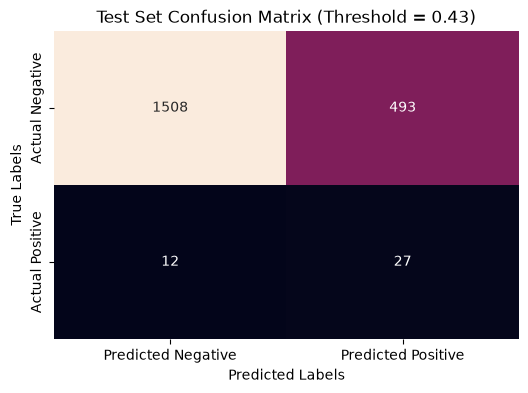

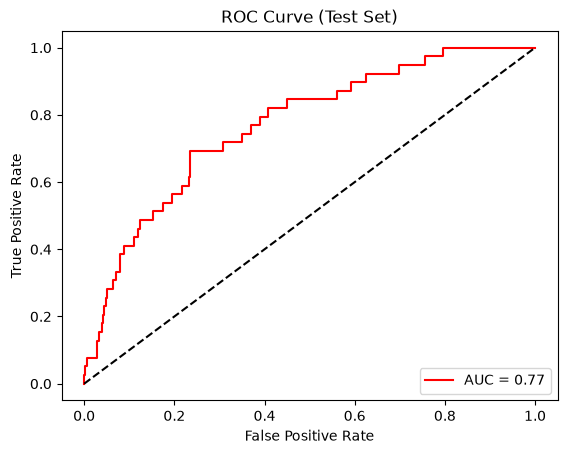

In [255]:
test_probs = pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_thresh).astype(int)

cm = confusion_matrix(y_test, test_preds)
print(f"--- Confusion Matrix (threshold = {best_thresh:.2f}) ---")
print(cm)
print(f"\n--- Classification Report (threshold = {best_thresh:.2f}) ---")
print(classification_report(y_test, test_preds))

roc_auc = roc_auc_score(y_test, test_probs)
print(f"ROC-AUC: {roc_auc:.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title(f'Test Set Confusion Matrix (Threshold = {best_thresh:.2f})')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_probs)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='red')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.show()


In [256]:
# test_probs = pipeline.predict_proba(X_test)[:, 1]
# test_preds = (test_probs >= best_thresh).astype(int)

# cm = confusion_matrix(y_test, test_preds)
# print(f"--- Confusion Matrix (threshold = {best_thresh:.2f}) ---")
# print(cm)
# print(f"\n--- Classification Report (threshold = {best_thresh:.2f}) ---")
# print(classification_report(y_test, test_preds))

# roc_auc = roc_auc_score(y_test, test_probs)
# print(f"ROC-AUC: {roc_auc:.4f}")

# plt.figure(figsize=(6, 4))
# sns.heatmap(cm, annot=True, fmt='d', cbar=False,
#             xticklabels=['Predicted Negative', 'Predicted Positive'],
#             yticklabels=['Actual Negative', 'Actual Positive'])
# plt.title(f'Test Set Confusion Matrix (Threshold = {best_thresh:.2f})')
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.show()

# fpr, tpr, _ = roc_curve(y_test, test_probs)
# plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='red')
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve (Test Set)')
# plt.legend(loc='lower right')
# plt.show()


### 5. Save the *whole pipeline* (encoder + scaler + model together)

This is the key fix from before: previously the scaler and label encoders were never saved (or saved separately from the model), so new raw data couldn't be transformed the same way at inference time. Saving the full `Pipeline` object means one file handles raw input end-to-end — no manual encoding/scaling required at prediction time.


In [257]:
with open('fraud_pipeline.sav', 'wb') as f:
    pickle.dump(pipeline, f)

with open('decision_threshold.pkl', 'wb') as f:
    pickle.dump(best_thresh, f)

# Keep the raw (pre-pipeline) column names/order so inference input can be built correctly
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)

print("Saved: fraud_pipeline.sav, decision_threshold.pkl, model_columns.pkl")


Saved: fraud_pipeline.sav, decision_threshold.pkl, model_columns.pkl


### 6. Inference example — using the saved pipeline directly

Because the pipeline includes the encoder and scaler, a new prediction only needs the **raw** feature values (original category strings, unscaled amounts) — the pipeline handles the rest. This fixes the earlier bug where raw, unscaled/unencoded tuples were fed straight into the model.


In [258]:
# Load everything back exactly as it would be in a separate serving script
loaded_pipeline = pickle.load(open('fraud_pipeline.sav', 'rb'))
loaded_thresh = pickle.load(open('decision_threshold.pkl', 'rb'))
loaded_columns = pickle.load(open('model_columns.pkl', 'rb'))

# Example new transaction — raw values, same columns/order as X_train, no manual encoding/scaling needed
new_txn = pd.DataFrame([X_test.iloc[0]], columns=loaded_columns)

fraud_probability = loaded_pipeline.predict_proba(new_txn)[0, 1]
is_fraud_pred = int(fraud_probability >= loaded_thresh)

print("Fraud probability:", round(fraud_probability, 4))
print("Prediction:", "Fraud" if is_fraud_pred else "Not Fraud",
      f"(threshold = {loaded_thresh:.2f})")


Fraud probability: 0.2019
Prediction: Not Fraud (threshold = 0.43)


## Predictive System

In [ ]:
# Edit these values to test a different transaction — every field X_train was trained on
# must be present, using the SAME raw (pre-encoding) categories as the original data.
single_transaction = {
    'home_country': 'us',
    'source_currency': 'USD',
    'dest_currency': 'EUR',
    'channel': 'mobile',
    'amount_src': 850.00,
    'amount_usd': 850.00,
    'fee': 12.50,
    'new_device': True,
    'location_mismatch': True,
    'ip_risk_score': 0.82,
    'kyc_tier': 'standard',
    'account_age_days': 14,
    'device_trust_score': 0.21,
    'chargeback_history_count': 1,
    'risk_score_internal': 0.77,
    'txn_velocity_1h': 4,
    'txn_velocity_24h': 11,
    'corridor_risk': 0.65,
    'hour': 2,
    'day_of_week': 'Saturday',
    'is_weekend': 1,
}

# Build a one-row DataFrame with columns in the exact order the pipeline expects
single_df = pd.DataFrame([single_transaction], columns=loaded_columns)

fraud_probability = loaded_pipeline.predict_proba(single_df)[0, 1]
is_fraud_pred = int(fraud_probability >= loaded_thresh)

print("Fraud probability:", round(fraud_probability, 4))
print("Prediction:", "Fraud Attempt" if is_fraud_pred else "Not Fraud",
    f"(threshold = {loaded_thresh:.2f})")


Fraud probability: 0.4546
Prediction: Fraud Attempt (threshold = 0.43)
